# Cross-Market Correlation Strategy: BTC & NASDAQ Futures

## Project Objective and Approach
This project aims to enhance the performance of a systematic trading strategy through the application of machine-learning techniques. A baseline rule-based strategy is first evaluated using historical backtesting to establish benchmark performance. Its limitations are then systematically analyzed, after which an appropriate machine-learning model is applied to address the identified weaknesses. The effectiveness of the proposed approach is evaluated by comparing trading performance before and after the integration of machine learning.

# Phase 1 - Problem Definition & Hypothesis Formulation

## Hypothesis
At short intraday time scales, directional agreement between Bitcoin (BTC) and NASDAQ-100 (NQ) futures reflects more stable market conditions, whereas directional divergence indicates increased market uncertainty and reduced trend persistence.

### Objective
To test whether short-horizon cross-asset directional relationships contain information that can be exploited in a systematic trading strategy.

## Data Collection

For this project (for both BTC and NASDAQ):

- **Assets:** BTCUSDT Perpetual Futures (filter) and NASDAQ-100 E-mini Futures (target)  
- **Interval:** 1-minute
- **Date range:** 1/12/2025 00:00 - 5/12/2025 23:00 
- **Data Source**: Historical data was manually downloaded from TradingView

## Data Preprocessing

After downloading the raw data, preprocessing was performed in Python:

1. Converted numeric columns from strings to floats for analysis  
2. Converted **UNIX** timestamps to **EST/NYC** timezone  


#### For BTC:
3. Constructed three datasets for the analysis:
   - **Full dataset**  
   - **Weekday dataset** 
   - **New York session dataset** 
   

In [ ]:
import pandas as pd
import datetime
import pytz

# Convert timestamps from UTC to New York timezone (EST) (handles DST automatically)
ny_tz = pytz.timezone('America/New_York')
df_M['Open Time'] = pd.to_datetime(df_M['Open Time'], unit='ms', utc=True).dt.tz_convert(ny_tz)
df_M['Close Time'] = pd.to_datetime(df_M['Close Time'], unit='ms', utc=True).dt.tz_convert(ny_tz)

# Construct datasets

# 1. Full dataset
df_full = df_M.copy()

# 2. Weekday dataset (exclude weekends only)
df_weekday = df_M[df_M['Open Time'].dt.weekday < 5]  # Monday=0, Sunday=6

# 3. New York session dataset (9:30–16:00 NY time)
session_start = datetime.time(9, 30)
session_end = datetime.time(16, 0)
df_ny_session = df_M[df_M['Open Time'].dt.time.between(session_start, session_end)]


# Check dataset sizes
print("Full dataset rows:", len(df_full))
print("Weekday dataset rows:", len(df_weekday))
print("NY session dataset rows:", len(df_ny_session))


##  Synchronized return series

In [ ]:
import pandas as pd
import numpy as np
import os

dataset_folder = os.path.join(os.getcwd(), "Datasets")

btc_file = os.path.join(dataset_folder, "btc_1min.csv")
nq_file  = os.path.join(dataset_folder, "nq_1min.csv")

btc = pd.read_csv(btc_file, sep=';')
nq  = pd.read_csv(nq_file, sep=';')

btc = btc.dropna(subset=["Time UTC+1"])
nq  = nq.dropna(subset=["Time UTC+1"])

def prepare_df(df):
    df = df.copy()
    
    # convert string timestamp to datetime
    df["timestamp"] = pd.to_datetime(df["Time UTC+1"], format="%d/%m/%Y %H:%M")
    
    # set as index
    df.set_index("timestamp", inplace=True)
    
    # keep only OHLCV
    df = df[["open", "high", "low", "close", "Volume"]]
    
    # ensure sorted
    df.sort_index(inplace=True)
    
    return df

btc = prepare_df(btc)
nq  = prepare_df(nq)

print(nq)

In [ ]:
#Compute log returns
btc["return"] = np.log(btc["close"]).diff()
nq["return"]  = np.log(nq["close"]).diff()

#Synchronize timestamps
common_index = btc.index.intersection(nq.index)
btc_sync = btc.loc[common_index]
nq_sync  = nq.loc[common_index]

#Combine returns
returns = pd.DataFrame({
    "BTC_return": btc_sync["return"],
    "NQ_return": nq_sync["return"]
}).dropna()

#Check
print("Synchronized returns head:\n", returns.head())
print("Total synchronized rows:", len(returns))
print(returns.describe())


##  Lead–Lag Correlation Analysis Across Multiple Lags

This step tests whether one market tends to move **before** the other, and if so, **by how many minutes**.

Specifically, we ask:
- Does **Bitcoin futures** tend to move before **Nasdaq futures**?
- Or does **Nasdaq futures** move before **Bitcoinfutures**?
- If a lead–lag relationship exists, what is the **time delay (lag)**?

This analysis represents the **core hypothesis test** for detecting latency effects and delayed information transmission between markets.

### Formal definition

Let:

- $r^{BTC}_t$ denote the **1-minute log return of Bitcoin** at time $t$
- $r^{NQ}_t$ denote the **1-minute log return of Nasdaq futures** at time $t$

A lead–lag correlation is defined as:

$$
\text{Corr}\left( r^{BTC}_t,\ r^{NQ}_{t+k} \right)
$$

for different values of the lag parameter $k$, where:

- $k > 0$: Bitcoin **leads**, Nasdaq futures **lags**
- $k < 0$: Nasdaq futures **leads**, Bitcoin **lags**
- $k = 0$: Contemporaneous (simultaneous) relationship

If we observe:
- **Statistically significant correlations** at positive lags (e.g. $k = +1$ or $+2$)
- But **weak or insignificant correlation** at $k = 0$

Then this implies:

> Bitcoin price movements tend to occur first, and Nasdaq futures react **1–2 minutes later**.

Such delayed responses indicate **predictive structure** and are precisely the type of signal exploited by **latency arbitrage and cross-market prediction models**.



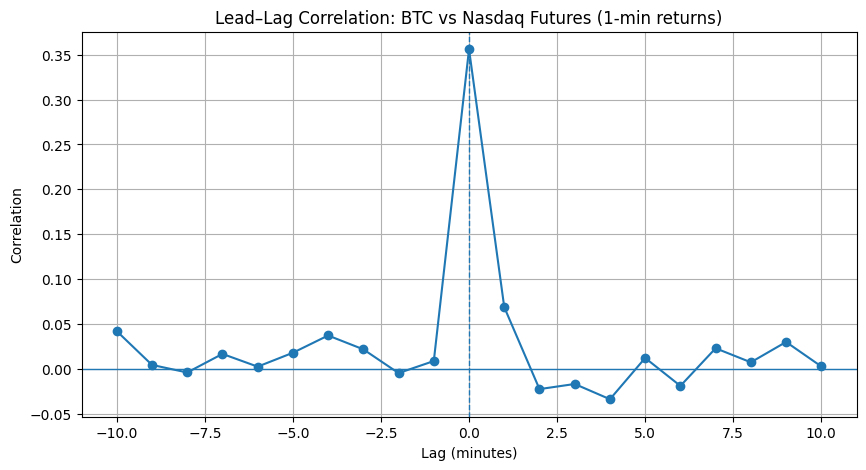

 0     0.356103
 1     0.068735
-10    0.042039
-4     0.037191
 9     0.029991
dtype: float64

In [55]:
import matplotlib.pyplot as plt

def lead_lag_correlation(series_x, series_y, max_lag=10):
    """"
    Computes lead–lag correlations Corr(X_t, Y_{t+k}) for k in [-max_lag, +max_lag].
    
    Parameters:
    series_x : pd.Series (e.g. BTC returns)
    series_y : pd.Series (e.g. NQ returns)
    max_lag  : int, maximum lag in minutes
    
    Returns:
    pd.Series indexed by lag
    """
    lags = range(-max_lag, max_lag + 1)
    correlations = []

    for k in lags:
        corr = series_x.corr(series_y.shift(k))
        correlations.append(corr)

    return pd.Series(correlations, index=lags)

max_lag = 10  # minutes

lead_lag_corr = lead_lag_correlation(
    returns["BTC_return"],
    returns["NQ_return"],
    max_lag=max_lag
)

lead_lag_corr

plt.figure(figsize=(10, 5))
plt.plot(lead_lag_corr.index, lead_lag_corr.values, marker='o')
plt.axhline(0, linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.title("Lead–Lag Correlation: BTC vs Nasdaq Futures (1-min returns)")
plt.xlabel("Lag (minutes)")
plt.ylabel("Correlation")

plt.grid(True)
plt.show()

lead_lag_corr.sort_values(ascending=False).head(5)


In [56]:
returns.corr()


,BTC_return,NQ_return
BTC_return,1.000000,0.356103
NQ_return,0.356103,1.000000


## Interpretation of Lead–Lag Correlation Results

Bitcoin and Nasdaq futures returns show a strong correlation at the **same minute** (about **0.36**), meaning they usually move together almost instantly.

Correlations at other time lags are much weaker, with only a small peak when Bitcoin leads by **1 minute**, so there’s limited evidence of clear, consistent lead–lag effects.

This suggests that any lead–lag relationship is likely **conditional**, appearing only in certain market conditions.


## Initial Volatility and Microstructure Diagnostics

Before analyzing lead–lag patterns, we first examine how the markets behave at the 1-minute level. This helps us understand whether observed relationships are meaningful or just noise.

### Methodology

1. **Compute 1-minute log returns**  

$$
r_t = \ln(P_t) - \ln(P_{t-1})
$$  

where $ P_t $ is the close price at minute $ t $.

2. **Check volatility**  
   - Calculate standard deviation and rolling volatility to spot periods of high or low activity.

3. **Inspect microstructure**  
   - Look at trading volume, gaps, and missing data.  
   - Examine return autocorrelations to detect bid-ask bounce or sticky prices.


#### Why this matters 
   - High volatility can amplify predictive signals.  
   - Low liquidity or noisy data can create misleading correlations.  
   - Understanding these factors ensures the lead–lag analysis is reliable.


BTC return autocorrelation (1 lag): 0.003847005198019412
NQ return autocorrelation (1 lag): 0.04957585970124872
BTC missing data: open          0
high          0
low           0
close         0
Volume        0
return        1
vol_5min      5
vol_15min    15
dtype: int64
NQ missing data: open          0
high          0
low           0
close         0
Volume        0
return        1
vol_5min      5
vol_15min    15
dtype: int64


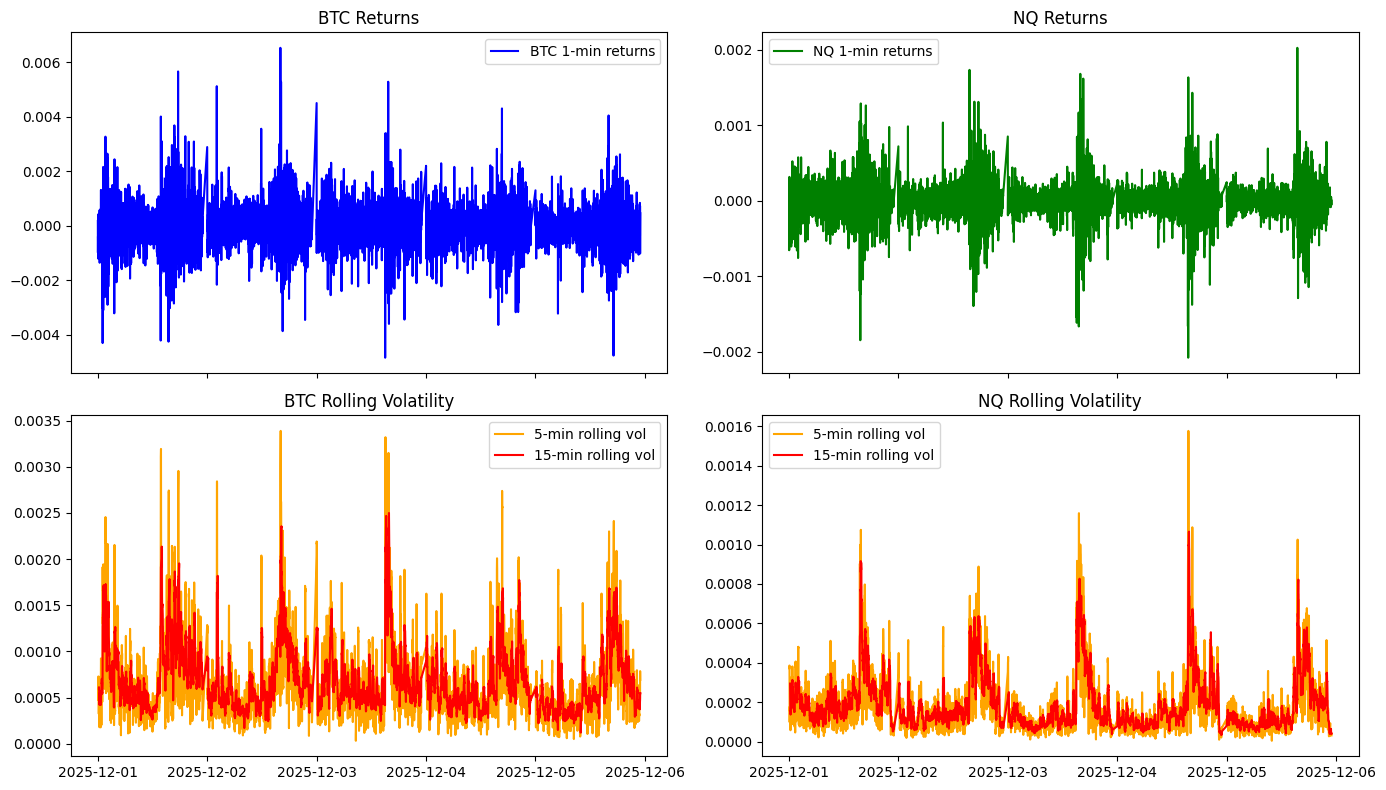

In [58]:
# Initial Volatility & Microstructure Diagnostics

import matplotlib.pyplot as plt

# 1️⃣ Compute 1-minute log returns (if not already done)
btc["return"] = np.log(btc["close"]).diff()
nq["return"]  = np.log(nq["close"]).diff()

# 2️⃣ Rolling volatility (5-min and 15-min windows)
btc["vol_5min"] = btc["return"].rolling(window=5).std()
btc["vol_15min"] = btc["return"].rolling(window=15).std()

nq["vol_5min"] = nq["return"].rolling(window=5).std()
nq["vol_15min"] = nq["return"].rolling(window=15).std()

# 3️⃣ Quick microstructure checks
print("BTC return autocorrelation (1 lag):", btc["return"].autocorr(lag=1))
print("NQ return autocorrelation (1 lag):", nq["return"].autocorr(lag=1))

print("BTC missing data:", btc.isna().sum())
print("NQ missing data:", nq.isna().sum())

# 4️⃣ Plot returns and rolling volatility
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# BTC
axes[0, 0].plot(btc["return"], label="BTC 1-min returns", color="blue")
axes[0, 0].set_title("BTC Returns")
axes[0, 0].legend()

axes[1, 0].plot(btc["vol_5min"], label="5-min rolling vol", color="orange")
axes[1, 0].plot(btc["vol_15min"], label="15-min rolling vol", color="red")
axes[1, 0].set_title("BTC Rolling Volatility")
axes[1, 0].legend()

# NQ
axes[0, 1].plot(nq["return"], label="NQ 1-min returns", color="green")
axes[0, 1].set_title("NQ Returns")
axes[0, 1].legend()

axes[1, 1].plot(nq["vol_5min"], label="5-min rolling vol", color="orange")
axes[1, 1].plot(nq["vol_15min"], label="15-min rolling vol", color="red")
axes[1, 1].set_title("NQ Rolling Volatility")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### Interpretation of Volatility & Microstructure Diagnostics

1. **Autocorrelation (1-lag)**  
   - BTC: 0.0038 → essentially zero, indicating no strong short-term autocorrelation.  
   - NQ: 0.0496 → very weak positive autocorrelation at 1-minute lag.  
   **Interpretation:** Both markets are relatively efficient at the 1-minute level; there is little predictable momentum from one minute to the next.

2. **Missing Data**  
   - BTC and NQ have **no missing OHLCV values**, but rolling calculations (5-min and 15-min volatility) naturally introduce NaNs at the start of the series.  
   **Interpretation:** Data quality is good; missing values do not pose a problem for analysis.

3. **Rolling Volatility**  
   - Visual inspection of 5-minute and 15-minute rolling volatility captures periods of higher and lower market activity.  
   **Interpretation:** These patterns can influence the strength of any lead–lag relationships and help identify conditional signals.

**Conclusion:**  
At the 1-minute horizon, both BTC and NQ show clean, low-autocorrelation returns with well-behaved volatility. This supports the reliability of subsequent lead–lag correlation analysis and latency arbitrage tests.


In [49]:
# 1-minute volatility (standard deviation of returns)
btc_vol_1min = returns["BTC_return"].std()
nq_vol_1min  = returns["NQ_return"].std()

# Annualized volatility (assuming 252 trading days, 1440 minutes/day)
btc_vol_ann = btc_vol_1min * np.sqrt(252*1440)
nq_vol_ann  = nq_vol_1min  * np.sqrt(252*1440)

print(f"BTC 1-min volatility: {btc_vol_1min:.6f}, annualized: {btc_vol_ann:.2%}")
print(f"NQ 1-min volatility:  {nq_vol_1min:.6f}, annualized: {nq_vol_ann:.2%}")


BTC 1-min volatility: 0.000775, annualized: 46.71%
NQ 1-min volatility:  0.000236, annualized: 14.20%


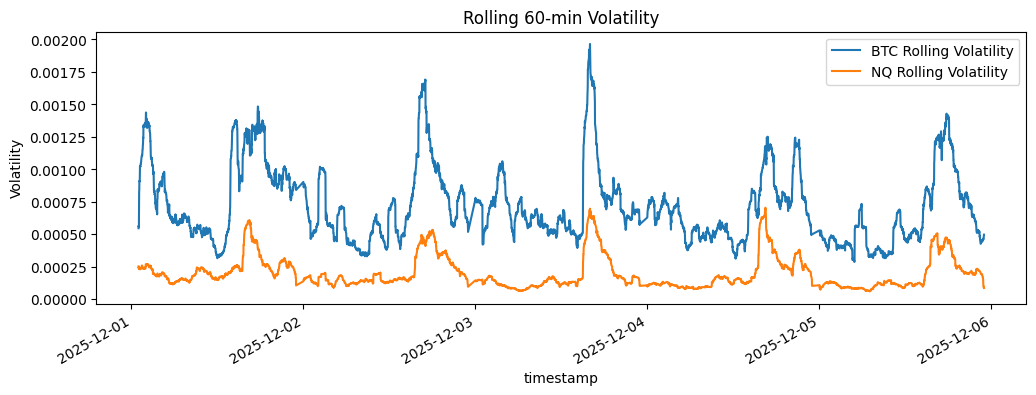

In [50]:
window = 60  # 60 minutes rolling
btc_vol_rolling = returns["BTC_return"].rolling(window).std()
nq_vol_rolling  = returns["NQ_return"].rolling(window).std()

btc_vol_rolling.plot(label='BTC Rolling Volatility', figsize=(12,4))
nq_vol_rolling.plot(label='NQ Rolling Volatility')
plt.title(f"Rolling {window}-min Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.show()


In [51]:
btc_gaps = (returns["BTC_return"].abs() > 0.01).sum()  # arbitrary threshold for large jumps
nq_gaps  = (returns["NQ_return"].abs() > 0.01).sum()
print(f"BTC large jumps (>1%): {btc_gaps}")
print(f"NQ large jumps  (>1%): {nq_gaps}")


BTC large jumps (>1%): 0
NQ large jumps  (>1%): 0


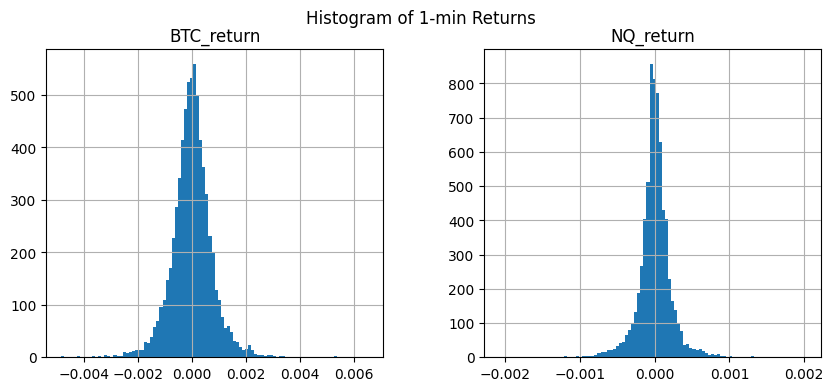

In [53]:
returns.hist(bins=100, figsize=(10,4))
plt.suptitle("Histogram of 1-min Returns")
plt.show()
